# **Settings**

## Variables

In [1]:
MEASUREMENTS = ['TA', 'RH', 'PA', 'PPFD', 'SW', 'LW', 'G','SWC', 'TS', 'PREC']  # Measurement name
FIELDS = ['PREC_M1_2_1',
          'TA_M1_2_1', 
          'RH_M1_2_1', 
          'PA_M1_2_1', 
          'PPFD_IN_T1_2_1',
          'SW_BC_IN_T1_2_1', 'SW_IN_T1_2_1', 'SW_BC_OUT_T1_2_1', 'SW_OUT_T1_2_1',
          'LW_BC_IN_T1_2_1', 'LW_IN_T1_2_1', 'LW_BC_OUT_T1_2_1', 'LW_OUT_T1_2_1',
          'SWC_CF2_0.05_1', 'SWC_CF2_0.15_1', 'SWC_CF2_0.3_1',
          'SWC_CF3_0.05_3', 'SWC_CF3_0.1_3', 'SWC_CF3_0.2_3', 'SWC_CF3_0.3_3', 'SWC_CF3_0.4_3', 'SWC_CF3_0.5_3', # SOIL VUE
          'TS_CF2_0.05_1', 'TS_CF2_0.15_1', 'TS_CF2_0.3_1',
          'TS_CF3_0.05_3', 'TS_CF3_0.1_3', 'TS_CF3_0.2_3', 'TS_CF3_0.3_3', 'TS_CF3_0.4_3', 'TS_CF3_0.5_3', # SOIL VUE
          'G_CF1_0.05_1'
          ]

## Database settings (used for example data)

In [2]:
# Settings for database download
SITE = 'ch-tan'  # Site name
START = '2023-11-01 00:00:00'  # Download data starting with this date
STOP = '2025-06-05 00:00:00'  # Download data before this date (the stop date itself is not included)
DATA_VERSION = 'meteoscreening_diive'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
data_version = "meteoscreening_diive"
DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configurations

</br>

# **Imports**

In [4]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

from dbc_influxdb import dbcInflux

from diive.core.plotting.heatmap_datetime import HeatmapDateTime  # For plotting heatmaps
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.pkgs.formats.meteo import FormatMeteoForFluxnetUpload  # Class to format output files for upload

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


</br>

# **Docstring**

In [31]:
# help(FormatMeteoForEddyProProcessing)

</br>

# **Load example data**
- This example uses data from a database.

In [5]:
dbc = dbcInflux(dirconf=DIRCONF)
df, _, _ = \
    dbc.download(bucket=f'{SITE}_processed',
                 measurements=MEASUREMENTS,
                 fields=FIELDS,
                 start=START,
                 stop=STOP,
                 timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
                 data_version=DATA_VERSION)

Reading configuration files was successful.
Connection to database works.

DOWNLOADING
    from bucket ch-tan_processed
    variables ['PREC_M1_2_1', 'TA_M1_2_1', 'RH_M1_2_1', 'PA_M1_2_1', 'PPFD_IN_T1_2_1', 'SW_BC_IN_T1_2_1', 'SW_IN_T1_2_1', 'SW_BC_OUT_T1_2_1', 'SW_OUT_T1_2_1', 'LW_BC_IN_T1_2_1', 'LW_IN_T1_2_1', 'LW_BC_OUT_T1_2_1', 'LW_OUT_T1_2_1', 'SWC_CF2_0.05_1', 'SWC_CF2_0.15_1', 'SWC_CF2_0.3_1', 'SWC_CF3_0.05_3', 'SWC_CF3_0.1_3', 'SWC_CF3_0.2_3', 'SWC_CF3_0.3_3', 'SWC_CF3_0.4_3', 'SWC_CF3_0.5_3', 'TS_CF2_0.05_1', 'TS_CF2_0.15_1', 'TS_CF2_0.3_1', 'TS_CF3_0.05_3', 'TS_CF3_0.1_3', 'TS_CF3_0.2_3', 'TS_CF3_0.3_3', 'TS_CF3_0.4_3', 'TS_CF3_0.5_3', 'G_CF1_0.05_1']
    from measurements ['TA', 'RH', 'PA', 'PPFD', 'SW', 'LW', 'G', 'SWC', 'TS', 'PREC']
    from data version ['meteoscreening_diive']
    between 2023-11-01 00:00:00 and 2025-06-05 00:00:00
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-tan_processed") |> range(start: 2023-11-01T00:00:00+01:00, stop: 20

The dataframe with original data looks like this:

In [6]:
df

,G_CF1_0.05_1,LW_BC_IN_T1_2_1,LW_BC_OUT_T1_2_1,LW_IN_T1_2_1,LW_OUT_T1_2_1,PA_M1_2_1,PPFD_IN_T1_2_1,PREC_M1_2_1,RH_M1_2_1,SWC_CF2_0.05_1,SWC_CF2_0.15_1,SWC_CF2_0.3_1,SWC_CF3_0.05_3,SWC_CF3_0.1_3,SWC_CF3_0.2_3,...,SWC_CF3_0.5_3,SW_BC_IN_T1_2_1,SW_BC_OUT_T1_2_1,SW_IN_T1_2_1,SW_OUT_T1_2_1,TA_M1_2_1,TS_CF2_0.05_1,TS_CF2_0.15_1,TS_CF2_0.3_1,TS_CF3_0.05_3,TS_CF3_0.1_3,TS_CF3_0.2_3,TS_CF3_0.3_3,TS_CF3_0.4_3,TS_CF3_0.5_3
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-18 23:30:00,-4.175582,NaN,NaN,NaN,NaN,95.558519,NaN,0.000,78.492593,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-19 00:00:00,-3.701263,NaN,NaN,NaN,NaN,95.507667,NaN,0.000,79.276667,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,7.706667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-19 00:30:00,-2.279430,NaN,NaN,NaN,NaN,95.470000,NaN,0.221,84.429999,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,7.573333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-19 01:00:00,-0.730810,NaN,NaN,NaN,NaN,95.467667,NaN,0.153,87.846667,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,7.533333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-19 01:30:00,0.000000,NaN,NaN,NaN,NaN,95.466667,NaN,0.204,89.633334,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,7.623333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:30:00,-25.106403,NaN,NaN,353.321647,392.177650,95.121000,0.0,0.017,82.716668,27.983877,29.086370,24.730949,18.070884,17.896644,18.536345,...,49.171181,NaN,NaN,0.0,0.0,15.786667,18.385555,18.675556,17.300000,17.802203,18.252201,18.110617,17.670830,16.863900,16.296347
2025-06-04 22:00:00,-23.907052,NaN,NaN,365.498643,392.441257,95.134000,0.0,0.017,82.700000,27.981393,29.086370,24.709643,18.329227,18.018475,18.882128,...,49.626688,NaN,NaN,0.0,0.0,15.693333,18.192778,18.566111,17.300000,17.638945,18.094945,18.042643,17.669967,16.876580,16.297180
2025-06-04 22:30:00,-22.316862,NaN,NaN,368.483990,391.171820,95.139333,0.0,0.034,84.423333,27.982679,29.086370,24.707201,18.053377,18.021240,18.685973,...,49.589873,NaN,NaN,0.0,0.0,15.516667,18.041666,18.451111,17.300000,17.515017,17.955672,17.975648,17.650989,16.876580,16.302190


</br>

# **Rename variables**

Merge variables with duplicated naming

In [7]:
df['sw_in'] = df['SW_BC_IN_T1_2_1'].combine_first(df['SW_IN_T1_2_1'])
df['sw_out'] = df['SW_BC_OUT_T1_2_1'].combine_first(df['SW_OUT_T1_2_1'])
df['lw_in'] = df['LW_BC_IN_T1_2_1'].combine_first(df['LW_IN_T1_2_1'])
df['lw_out'] = df['LW_BC_OUT_T1_2_1'].combine_first(df['LW_OUT_T1_2_1'])

df.drop(columns=['SW_BC_IN_T1_2_1', 'SW_IN_T1_2_1', 'SW_BC_OUT_T1_2_1', 'SW_OUT_T1_2_1', 'LW_BC_IN_T1_2_1', 'LW_IN_T1_2_1', 'LW_BC_OUT_T1_2_1', 'LW_OUT_T1_2_1'], inplace=True)

df

,G_CF1_0.05_1,PA_M1_2_1,PPFD_IN_T1_2_1,PREC_M1_2_1,RH_M1_2_1,SWC_CF2_0.05_1,SWC_CF2_0.15_1,SWC_CF2_0.3_1,SWC_CF3_0.05_3,SWC_CF3_0.1_3,SWC_CF3_0.2_3,SWC_CF3_0.3_3,SWC_CF3_0.4_3,SWC_CF3_0.5_3,TA_M1_2_1,TS_CF2_0.05_1,TS_CF2_0.15_1,TS_CF2_0.3_1,TS_CF3_0.05_3,TS_CF3_0.1_3,TS_CF3_0.2_3,TS_CF3_0.3_3,TS_CF3_0.4_3,TS_CF3_0.5_3,sw_in,sw_out,lw_in,lw_out
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-18 23:30:00,-4.175582,95.558519,NaN,0.000,78.492593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 00:00:00,-3.701263,95.507667,NaN,0.000,79.276667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.706667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 00:30:00,-2.279430,95.470000,NaN,0.221,84.429999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.573333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 01:00:00,-0.730810,95.467667,NaN,0.153,87.846667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.533333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 01:30:00,0.000000,95.466667,NaN,0.204,89.633334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.623333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:30:00,-25.106403,95.121000,0.0,0.017,82.716668,27.983877,29.086370,24.730949,18.070884,17.896644,18.536345,35.696237,36.838058,49.171181,15.786667,18.385555,18.675556,17.300000,17.802203,18.252201,18.110617,17.670830,16.863900,16.296347,0.0,0.0,353.321647,392.177650
2025-06-04 22:00:00,-23.907052,95.134000,0.0,0.017,82.700000,27.981393,29.086370,24.709643,18.329227,18.018475,18.882128,35.749257,36.137284,49.626688,15.693333,18.192778,18.566111,17.300000,17.638945,18.094945,18.042643,17.669967,16.876580,16.297180,0.0,0.0,365.498643,392.441257
2025-06-04 22:30:00,-22.316862,95.139333,0.0,0.034,84.423333,27.982679,29.086370,24.707201,18.053377,18.021240,18.685973,35.985671,36.224418,49.589873,15.516667,18.041666,18.451111,17.300000,17.515017,17.955672,17.975648,17.650989,16.876580,16.302190,0.0,0.0,368.483990,391.171820


In [8]:
# Rename original variables
rename_dict = {
    'TA_M1_2_1': 'ta',
    'RH_M1_2_1': 'rh',
    'PA_M1_2_1': 'pa',
    'PREC_M1_2_1': 'prec',
    'PPFD_IN_T1_2_1': 'ppfd', 
    'SW_OUT_T1_2_1': 'sw_out',
    'LW_IN_T1_2_1': 'lw_in', 
    'LW_OUT_T1_2_1': 'lw_out', 
    'SWC_CF2_0.05_1': 'swc_0.05',
    'SWC_CF2_0.15_1': 'swc_0.15',
    'SWC_CF2_0.3_1': 'swc_0.3',
    'SWC_CF3_0.05_3': 'swc_0.05_soilvue', 
    'SWC_CF3_0.1_3': 'swc_0.1_soilvue',
    'SWC_CF3_0.2_3': 'swc_0.2_soilvue',
    'SWC_CF3_0.3_3': 'swc_0.3_soilvue',
    'SWC_CF3_0.4_3': 'swc_0.4_soilvue',
    'SWC_CF3_0.5_3': 'swc_0.5_soilvue',
    'TS_CF2_0.05_1': 'ts_0.05', 
    'TS_CF2_0.15_1': 'ts_0.15', 
    'TS_CF2_0.3_1': 'ts_0.3',
    'TS_CF3_0.05_3': 'ts_0.05_soilvue', 
    'TS_CF3_0.1_3': 'ts_0.1_soilvue',
    'TS_CF3_0.2_3': 'ts_0.2_soilvue',
    'TS_CF3_0.3_3': 'ts_0.3_soilvue',
    'TS_CF3_0.4_3': 'ts_0.4_soilvue',
    'TS_CF3_0.5_3': 'ts_0.5_soilvue', 
    'G_CF1_0.05_1': 'g'
}

df.rename(columns=rename_dict, inplace=True)

</br>

# **Plot all variables**

C:\Users\turcof\AppData\Local\Temp\ipykernel_22192\3893439415.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(facecolor='white', figsize=(4, 8))


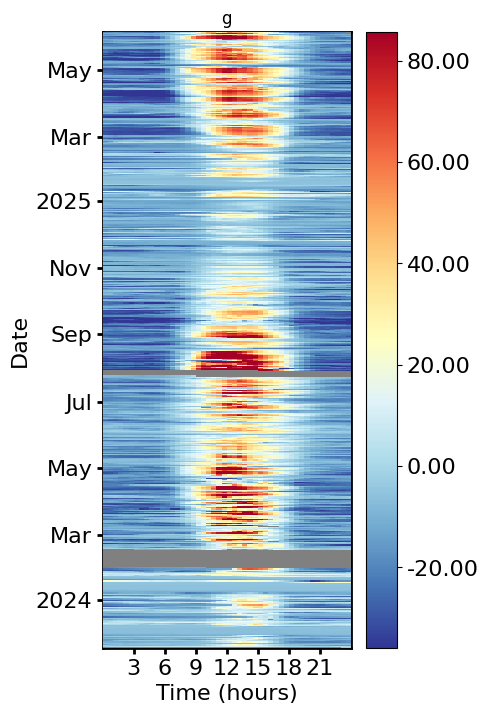

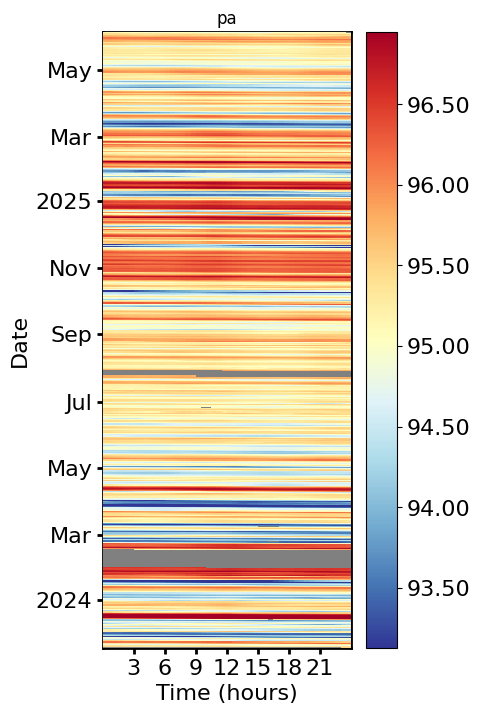

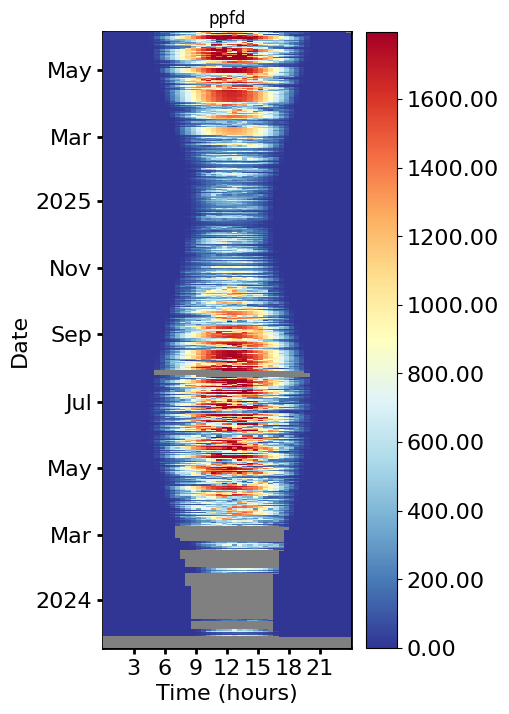

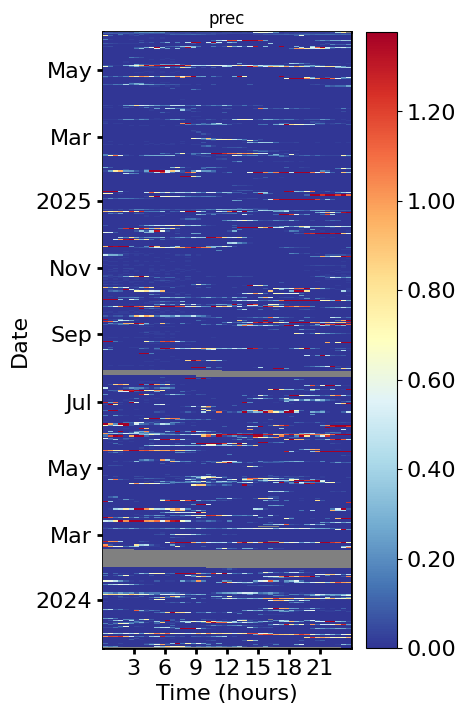

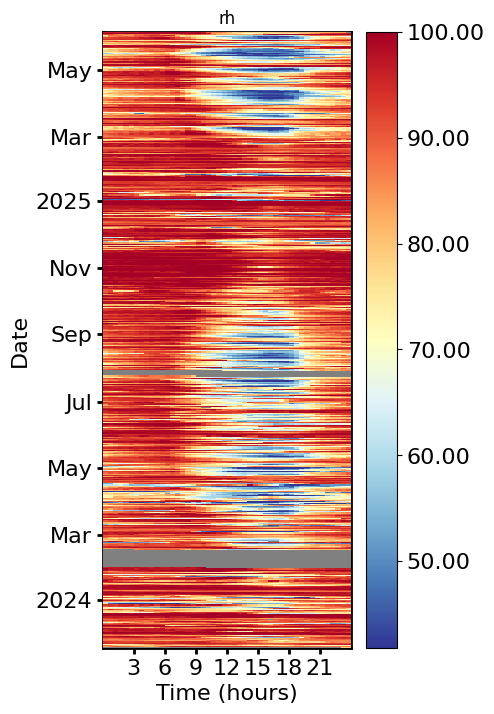

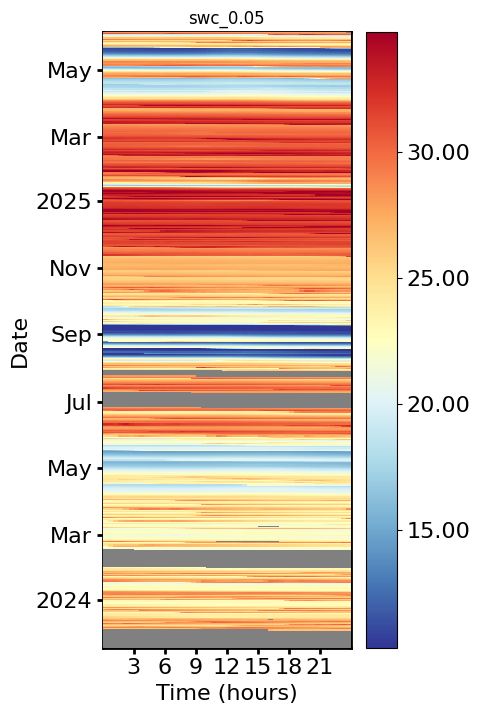

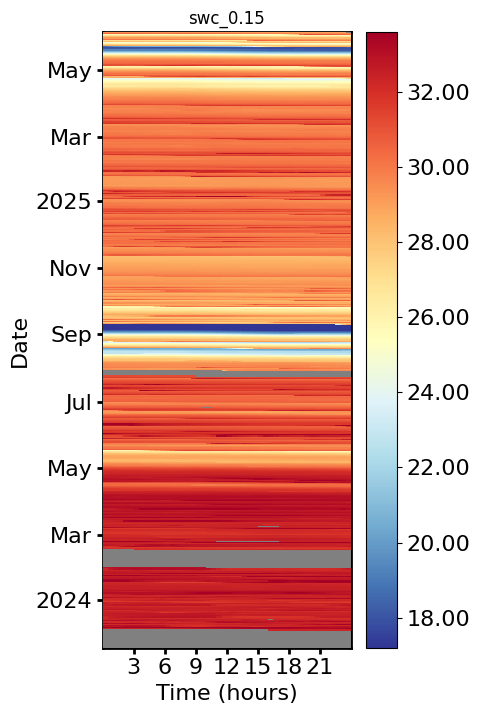

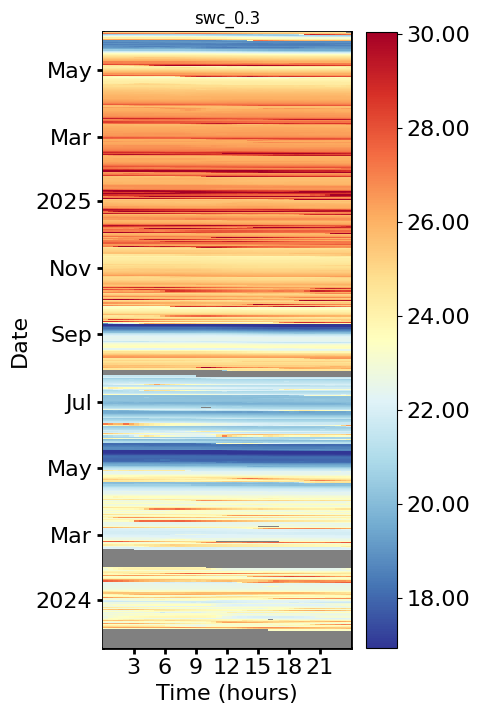

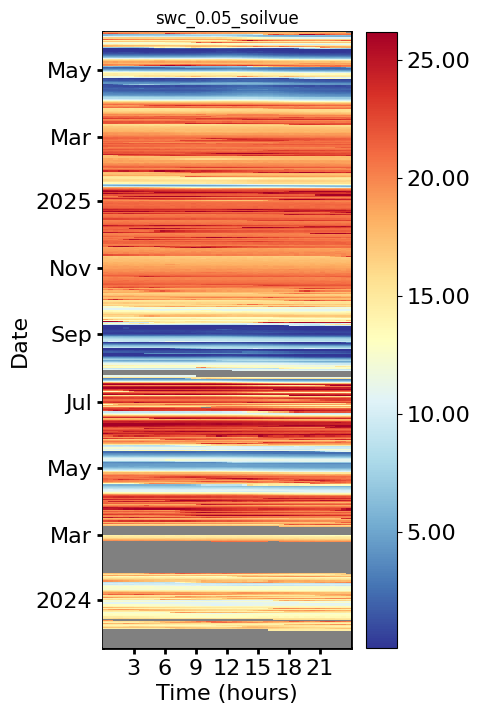

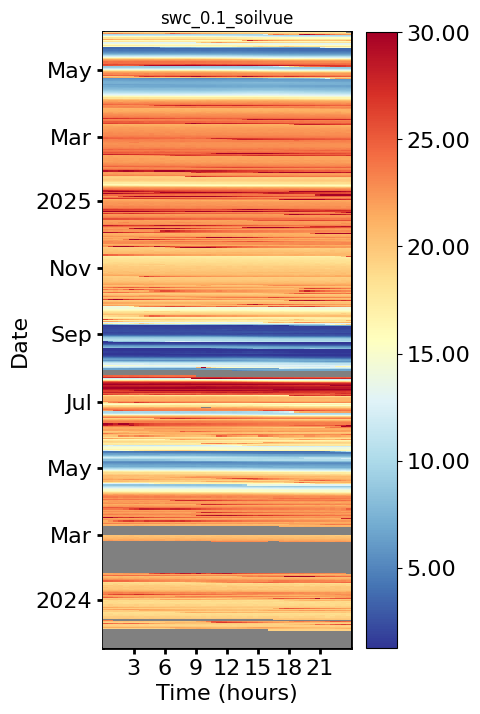

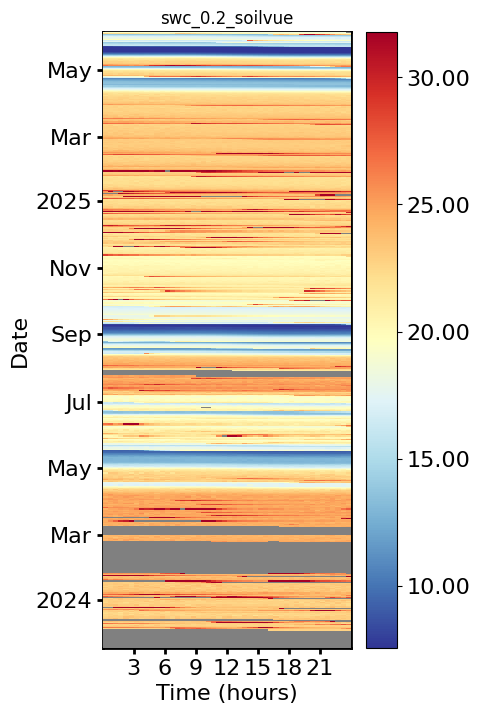

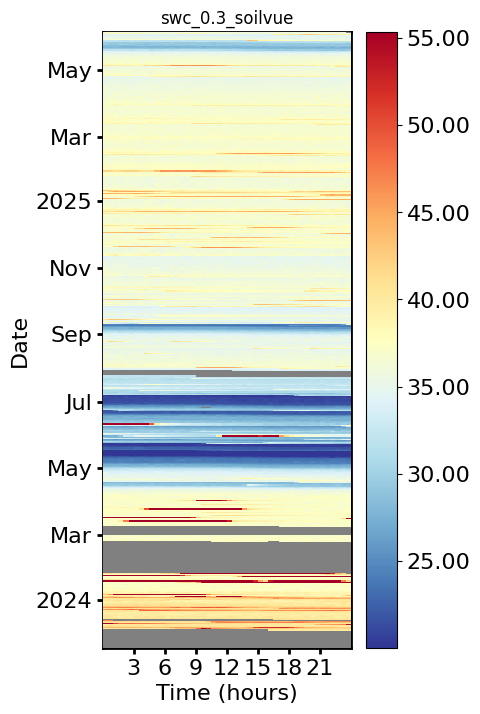

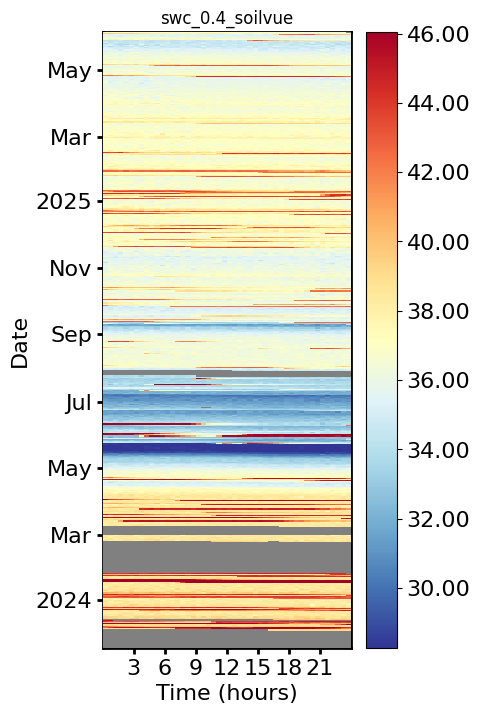

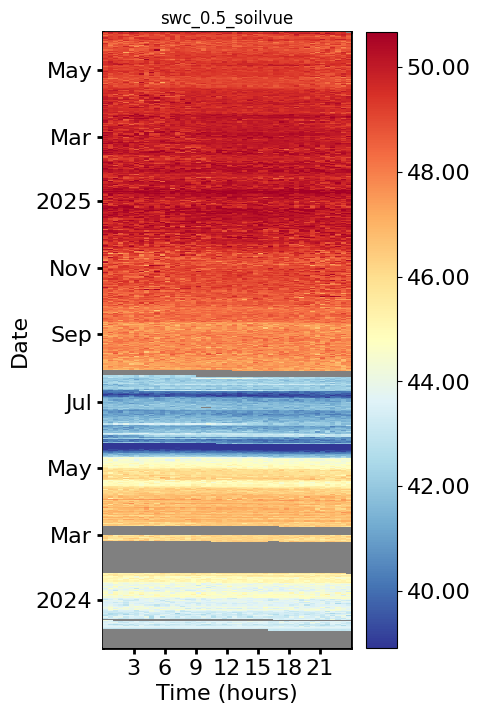

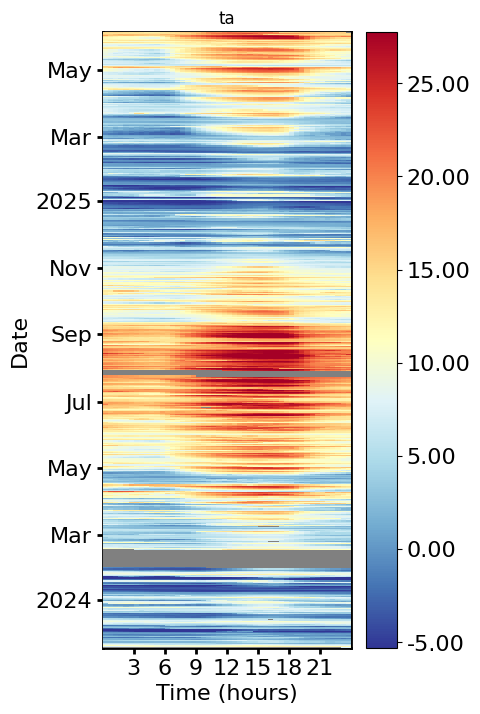

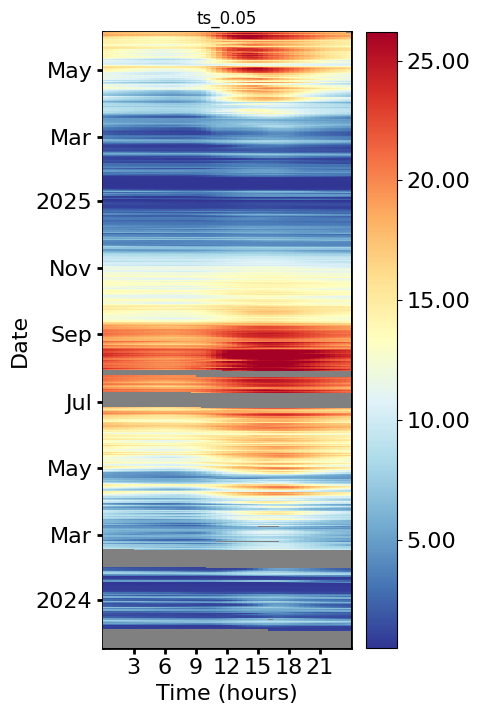

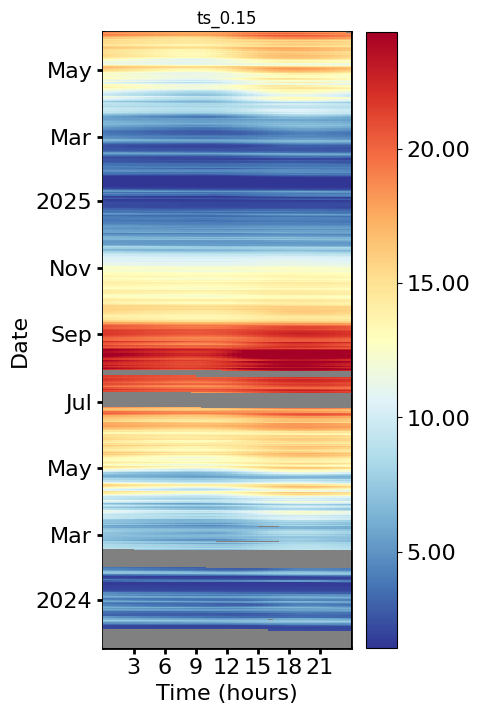

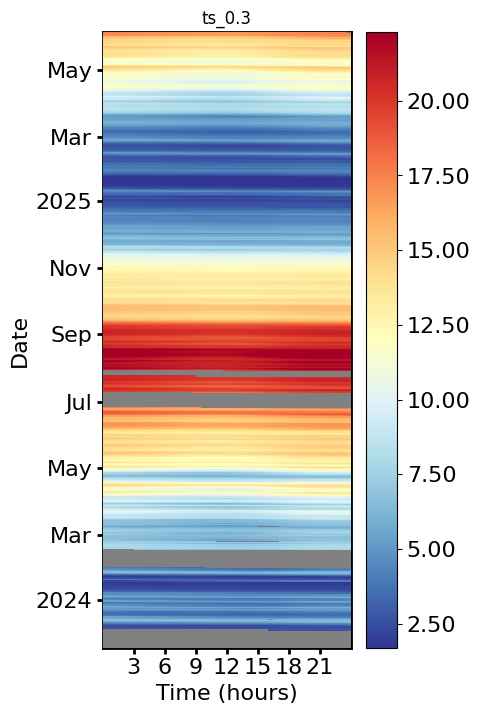

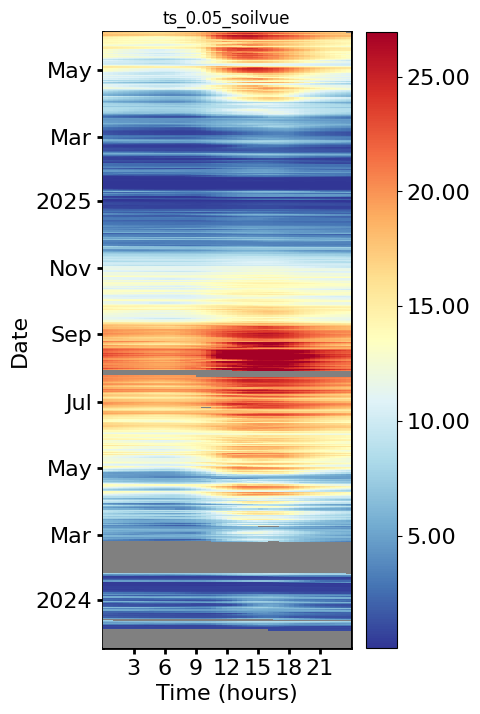

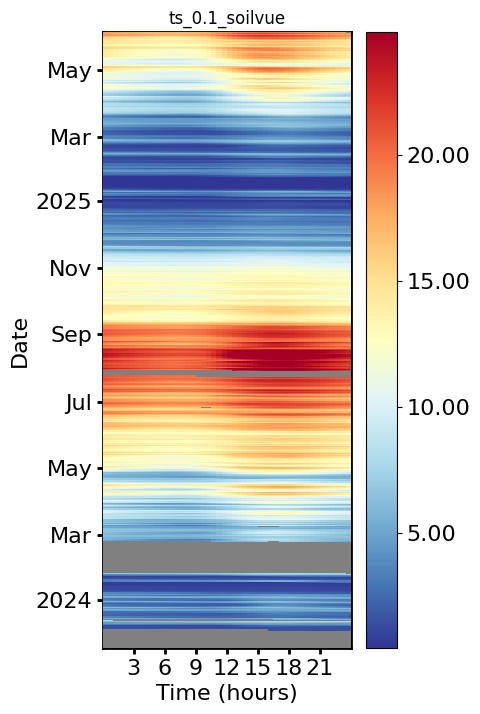

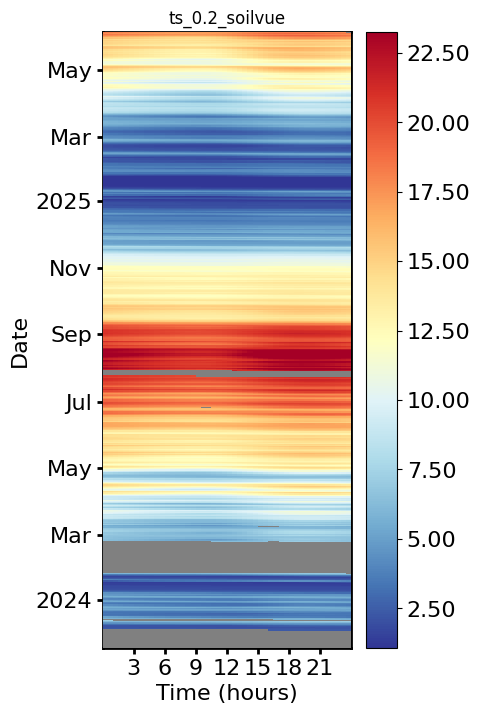

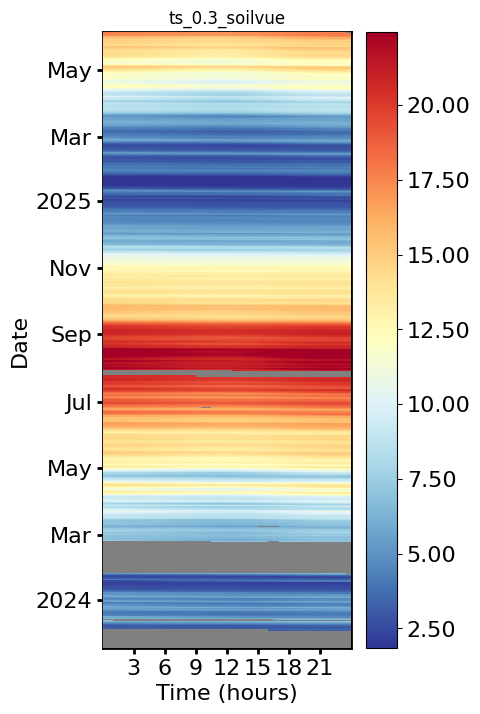

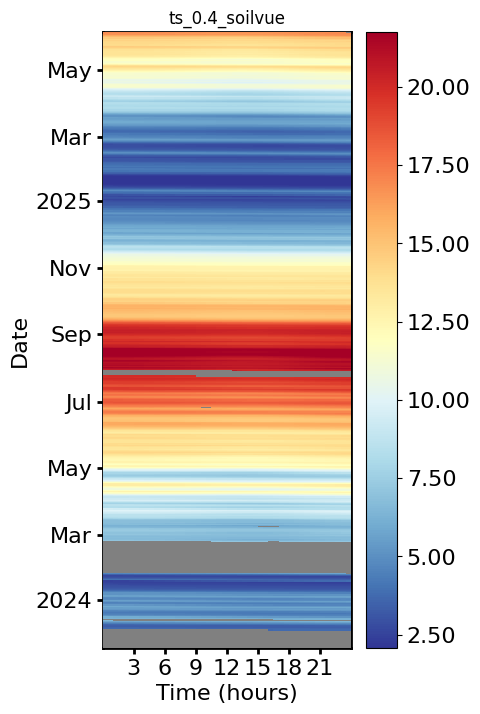

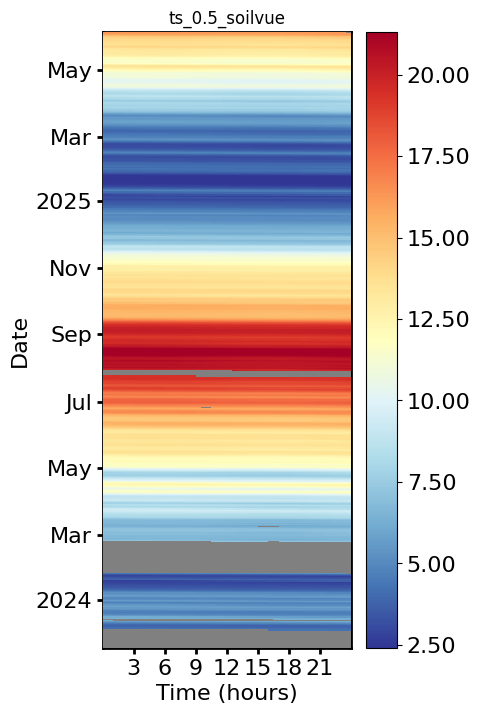

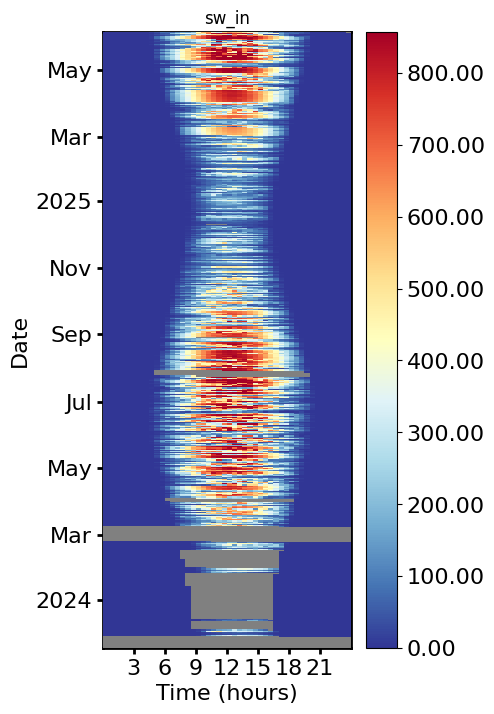

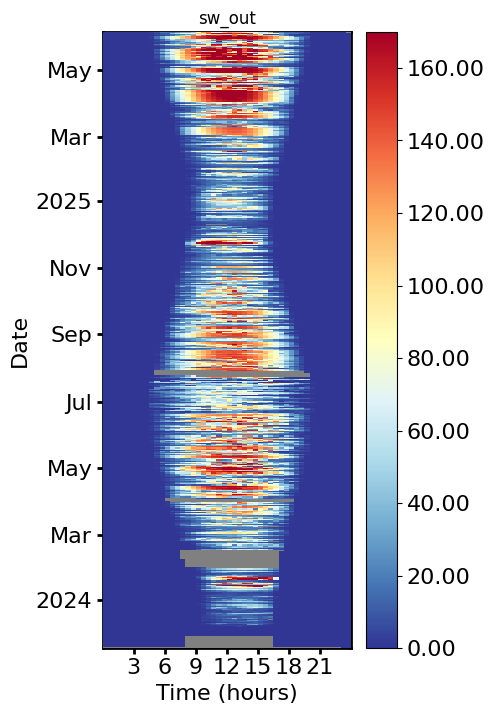

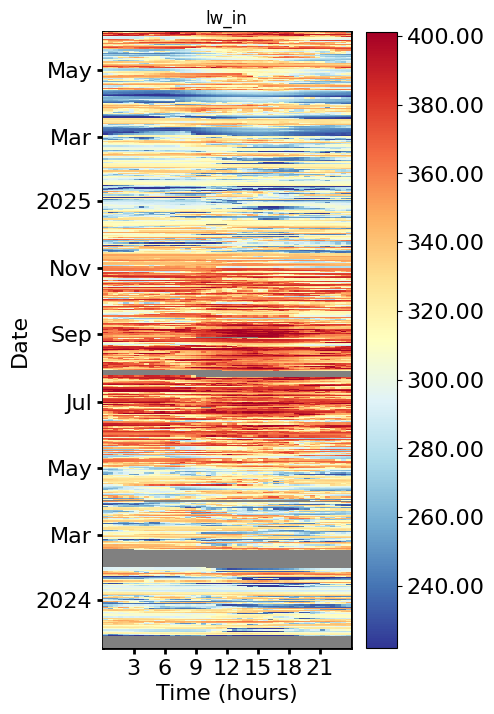

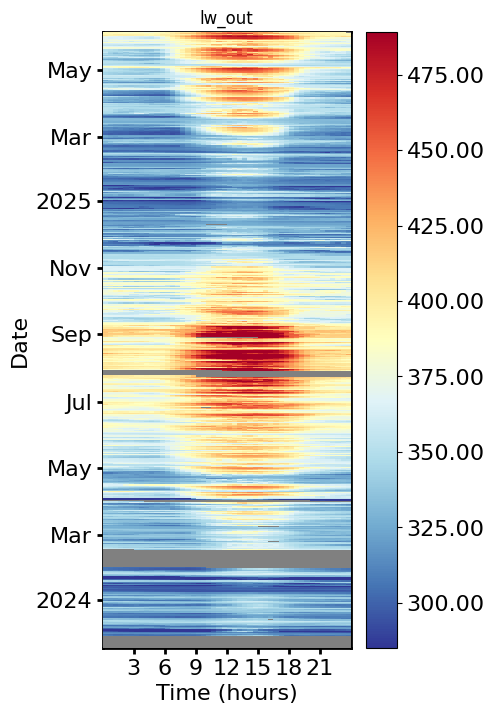

In [9]:
plotcols = [plotcol for plotcol in df.columns if not "TIMESTAMP" in plotcol]
plotdf = df[plotcols].copy()

for col in plotdf.columns:
    series = plotdf[col].copy()
    try:
        fig = plt.figure(facecolor='white', figsize=(4, 8))
        gs = gridspec.GridSpec(1, 1)  # rows, cols
        ax = fig.add_subplot(gs[0, 0])
        vmin = series.quantile(.01)
        vmax = series.quantile(.99)
        HeatmapDateTime(ax=ax, series=series, vmin=vmin, vmax=vmax).plot()
        ax.set_title(col, color='black')
        fig.show()
    except TypeError:
        pass

</br>

# **Save to CSV**

In [12]:
df.to_csv(f'11.1_CH-TAN_2023-25_ALL_METEO_meteoscreening_diive.csv')

</br>

# **End of notebook**

In [13]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-08-28 17:39:47
